# Librerias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

# Carga de los datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ONE/HACKATHON/DATASET/DF_FEATURE_ENGINNERING/dataset_feature_enginnering_final.csv')

In [ ]:
df.head(10)

,antiguedad,plan,metodo_pago,tipo_contrato,frecuencia_uso,cambios_plan,facturas_impagas,tickets_soporte,canal_adquisicion,friccion_del_servicio,engagement_score,valor_plan_num,ratio_valor_uso,riesgo_financiero,cliente_problematico,early_churn_risk,premium_mensual,churn
0,16,estandar,transferencia_bancaria,mensual,15,3,2,0,call_center,0.000000,0.360000,9.99,0.624375,19.98,0,0,0,0
1,120,estandar,efectivo,mensual,2,2,3,10,referido,3.333333,0.506667,9.99,3.330000,29.97,1,0,0,1
2,29,premium,tarjeta_credito,anual,28,3,2,1,web,0.034483,0.565833,14.99,0.516897,29.98,0,0,0,0
3,48,estandar,tarjeta_debito,mensual,9,1,0,2,referido,0.200000,0.480000,9.99,0.999000,0.00,0,0,0,0
4,13,estandar,tarjeta_credito,mensual,19,0,1,5,web,0.250000,0.585833,9.99,0.499500,9.99,0,0,0,0
5,2,estandar,tarjeta_credito,anual,0,3,2,5,redes_sociales,5.000000,0.125000,9.99,9.990000,19.98,0,1,0,1
6,45,premium,transferencia_bancaria,mensual,10,0,2,5,call_center,0.454545,0.545833,14.99,1.362727,29.98,0,0,1,0
7,40,estandar,efectivo,mensual,30,0,1,3,redes_sociales,0.096774,0.800000,9.99,0.322258,9.99,0,0,0,0
8,43,estandar,efectivo,anual,17,0,2,5,call_center,0.277778,0.634167,9.99,0.555000,19.98,0,0,0,0
9,33,estandar,transferencia_bancaria,anual,15,0,0,7,referido,0.437500,0.582500,9.99,0.624375,0.00,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4251 entries, 0 to 4250
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   antiguedad             4251 non-null   int64  
 1   plan                   4251 non-null   object 
 2   metodo_pago            4251 non-null   object 
 3   tipo_contrato          4251 non-null   object 
 4   frecuencia_uso         4251 non-null   int64  
 5   cambios_plan           4251 non-null   int64  
 6   facturas_impagas       4251 non-null   int64  
 7   tickets_soporte        4251 non-null   int64  
 8   canal_adquisicion      4251 non-null   object 
 9   friccion_del_servicio  4251 non-null   float64
 10  engagement_score       4251 non-null   float64
 11  valor_plan_num         4251 non-null   float64
 12  ratio_valor_uso        4251 non-null   float64
 13  riesgo_financiero      4251 non-null   float64
 14  cliente_problematico   4251 non-null   int64  
 15  earl

In [ ]:
df.isnull().sum()

,0
antiguedad,0
plan,0
metodo_pago,0
tipo_contrato,0
frecuencia_uso,0
cambios_plan,0
facturas_impagas,0
tickets_soporte,0
canal_adquisicion,0
friccion_del_servicio,0


El dataset no requería limpieza adicional.
Se realizara codificación One-Hot de variables categóricas para garantizar compatibilidad con modelos de machine learning y consumo por backend.

# ENCODING

Se separa las variables que ya cumplan con el encoding, en nuestro caso, la columna de churn ya cumple ese requisito

In [ ]:
X = df.drop(columns='churn')
y = df['churn']

columnas = X.columns

A continuacion se opta por separar las variables restantes en 2 tipos, las que tienen un sentido matematico y aquellas que son solo categorias
De este modo se crean 2 grupos, uno como 'num' y otro como 'cat'

In [ ]:
columnas_categoricas = ['plan', 'metodo_pago', 'tipo_contrato', 'canal_adquisicion']

columnas_numericas = [
    # Contractuales originales (6)
    'antiguedad',
    'frecuencia_uso',
    'cambios_plan',
    'facturas_impagas',
    'tickets_soporte',
    # Features engineerizadas (7)
    'friccion_del_servicio',
    'engagement_score',
    'valor_plan_num',
    'ratio_valor_uso',
    'riesgo_financiero',
    'cliente_problematico',
    'early_churn_risk',
    'premium_mensual'
]

Se empieza el tratado de los datos para hacerlos utilizables en un modelo

In [ ]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

columnas_cat = encoder.fit_transform(X[columnas_categoricas])

df_cat = pd.DataFrame(columnas_cat, columns=encoder.get_feature_names_out(columnas_categoricas))

df_codificado = pd.concat([X[columnas_numericas].reset_index(drop=True), df_cat.reset_index(drop=True)], axis=1)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
df_codificado['churn'] = y

print(df_codificado)
print(df_codificado.info())

      antiguedad  frecuencia_uso  ...  canal_adquisicion_web  churn
0             16              15  ...                    0.0      0
1            120               2  ...                    0.0      1
2             29              28  ...                    1.0      0
3             48               9  ...                    0.0      0
4             13              19  ...                    1.0      0
...          ...             ...  ...                    ...    ...
4246          49              16  ...                    1.0      0
4247          39              18  ...                    1.0      1
4248          20               7  ...                    0.0      1
4249          51              15  ...                    0.0      0
4250          60               4  ...                    0.0      1

[4251 rows x 23 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4251 entries, 0 to 4250
Data columns (total 23 columns):
 #   Column                              Non-Null C

In [ ]:
## Se utiliza un ColumnTransformer para aplicar transformaciones diferenciadas
## según el tipo de variable, preservando las numéricas y codificando las categóricas mediante One-Hot Encoding,
## evitando relaciones artificiales y garantizando compatibilidad con modelos de machine learning.

In [ ]:
df_codificado.head(10)

,antiguedad,frecuencia_uso,cambios_plan,facturas_impagas,tickets_soporte,friccion_del_servicio,engagement_score,valor_plan_num,ratio_valor_uso,riesgo_financiero,cliente_problematico,early_churn_risk,premium_mensual,plan_estandar,plan_premium,metodo_pago_tarjeta_credito,metodo_pago_tarjeta_debito,metodo_pago_transferencia_bancaria,tipo_contrato_mensual,canal_adquisicion_redes_sociales,canal_adquisicion_referido,canal_adquisicion_web,churn
0,16,15,3,2,0,0.000000,0.360000,9.99,0.624375,19.98,0,0,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0
1,120,2,2,3,10,3.333333,0.506667,9.99,3.330000,29.97,1,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
2,29,28,3,2,1,0.034483,0.565833,14.99,0.516897,29.98,0,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,48,9,1,0,2,0.200000,0.480000,9.99,0.999000,0.00,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0
4,13,19,0,1,5,0.250000,0.585833,9.99,0.499500,9.99,0,0,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0
5,2,0,3,2,5,5.000000,0.125000,9.99,9.990000,19.98,0,1,0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
6,45,10,0,2,5,0.454545,0.545833,14.99,1.362727,29.98,0,0,1,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0
7,40,30,0,1,3,0.096774,0.800000,9.99,0.322258,9.99,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0
8,43,17,0,2,5,0.277778,0.634167,9.99,0.555000,19.98,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,33,15,0,0,7,0.437500,0.582500,9.99,0.624375,0.00,0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0


In [ ]:
# Verificación de la Proporción de Cancelación (Churn)
print(df_codificado['churn'].value_counts())
print(df_codificado['churn'].value_counts(normalize=True)*100)
# Tasa de churn:
# False -> 74.65%
# True -> 25.34%

churn
0    3172
1    1079
Name: count, dtype: int64
churn
0    74.617737
1    25.382263
Name: proportion, dtype: float64


# Analisis de correlacion

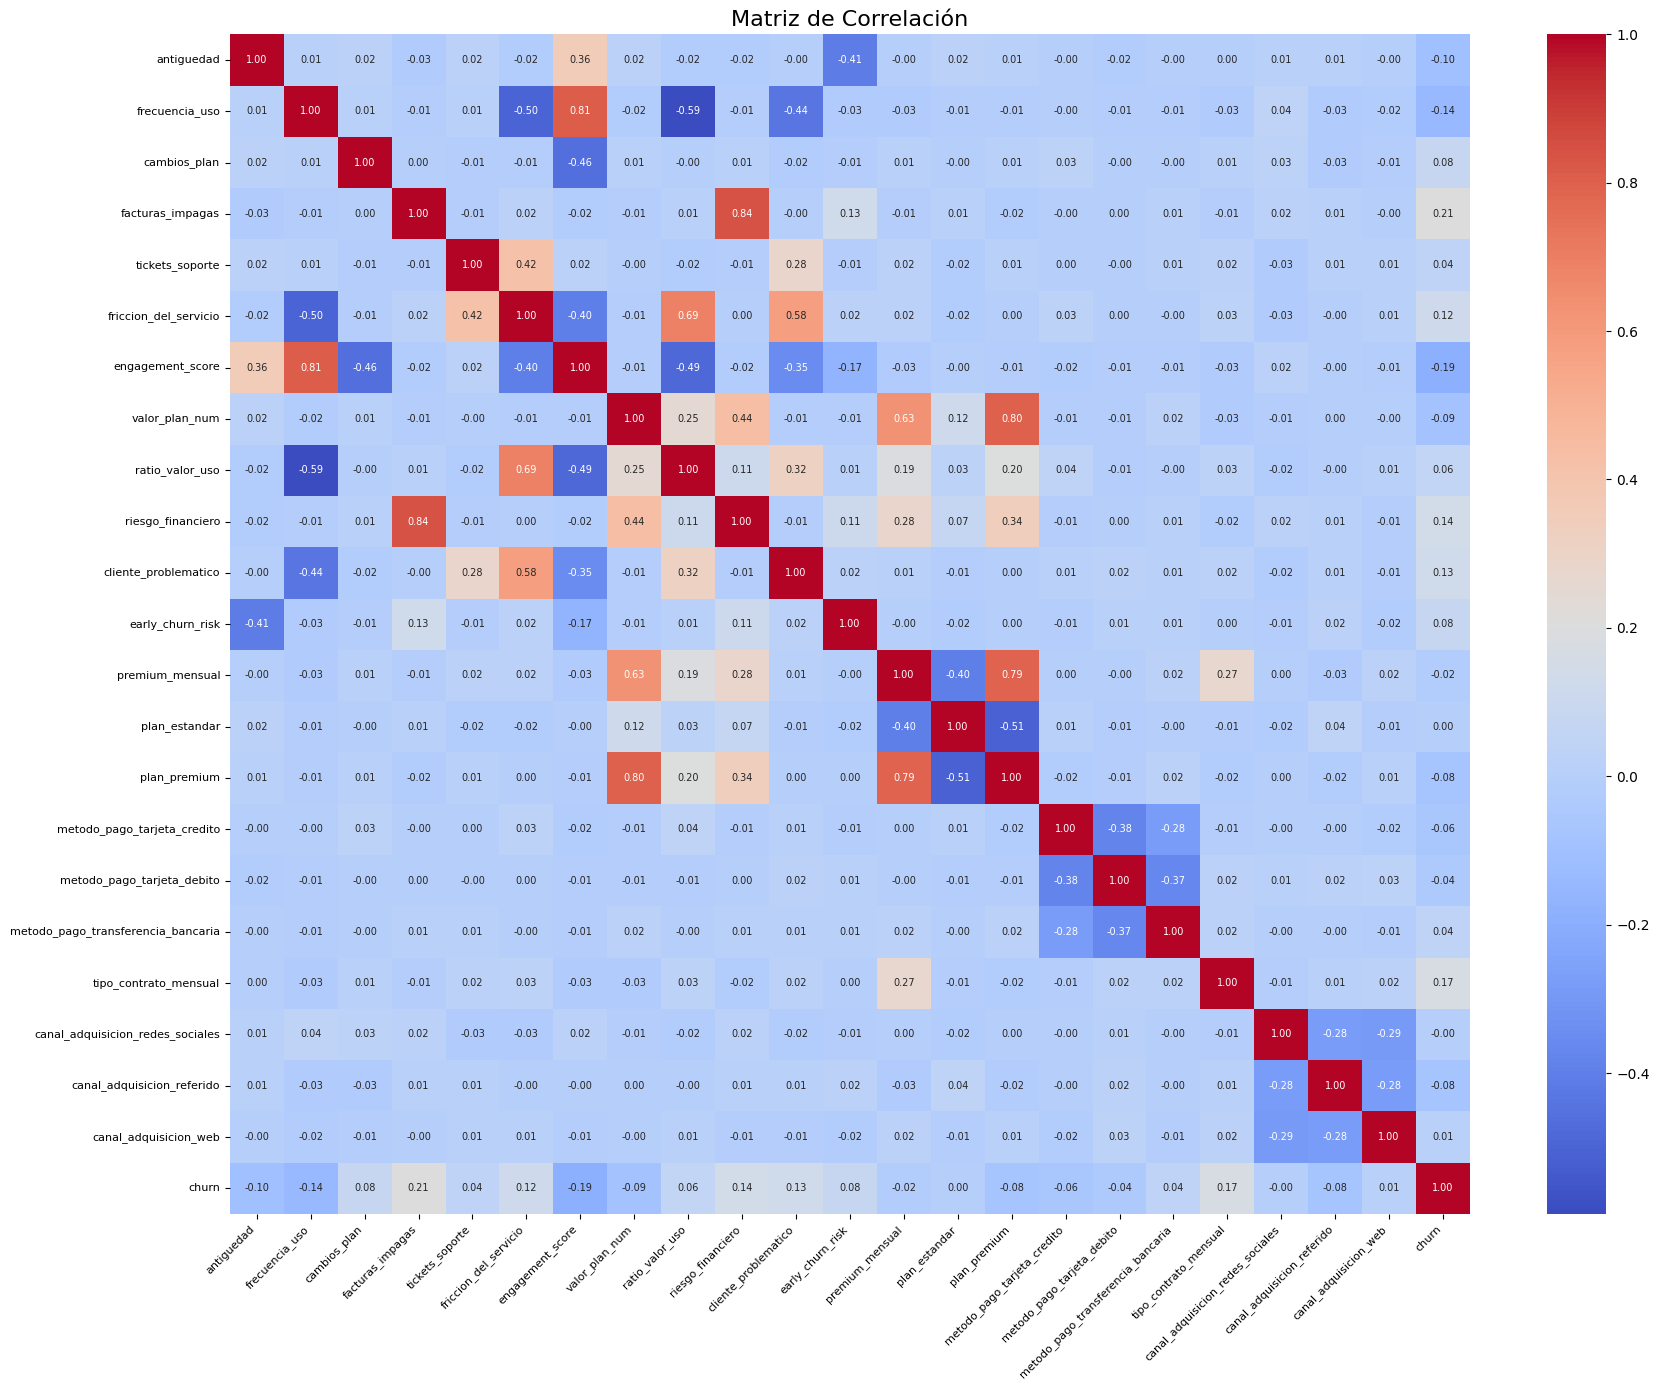

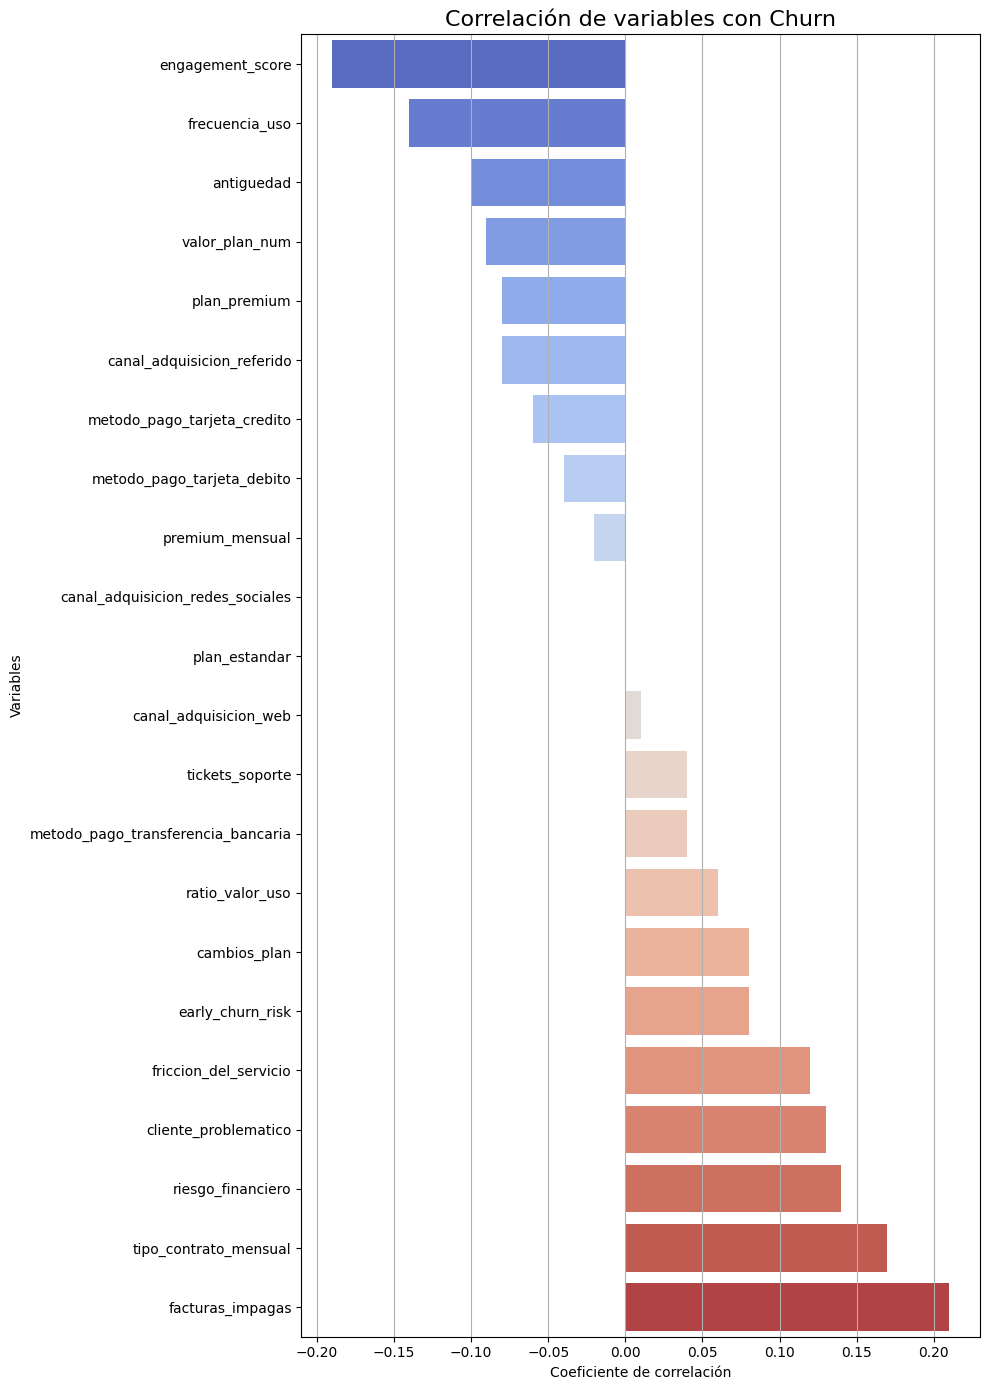

In [ ]:
# Analisis de correlación y multicolinearidad

corr = df_codificado.corr().round(2)

plt.figure(figsize=(18, 14))  # definimos el tamaño de figura
sns.heatmap(corr,
            annot=True,         # mostramos los valores de correlación dentro de cada celda
            fmt=".2f",
            cmap='coolwarm',    # paleta de colores
            annot_kws={"size": 7})  # reducimos el tamaño del texto dentro de las celdas

plt.xticks(rotation=45, ha='right', fontsize=8)  # rotamos y achicamos los ticks del eje x
plt.yticks(fontsize=8)                           # tamaño de fuente de los ticks del eje y
plt.title("Matriz de Correlación", fontsize=16)
plt.tight_layout()
plt.show()

# Visualizando mejor las correlaciones con la variable Churn

corr = corr.drop(index='churn').sort_values(by='churn', ascending=True)

plt.figure(figsize=(10, 14))
sns.barplot(
    x='churn',
    y=corr.index,
    data=corr,
    palette='coolwarm'
)
plt.title("Correlación de variables con Churn", fontsize=16)
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

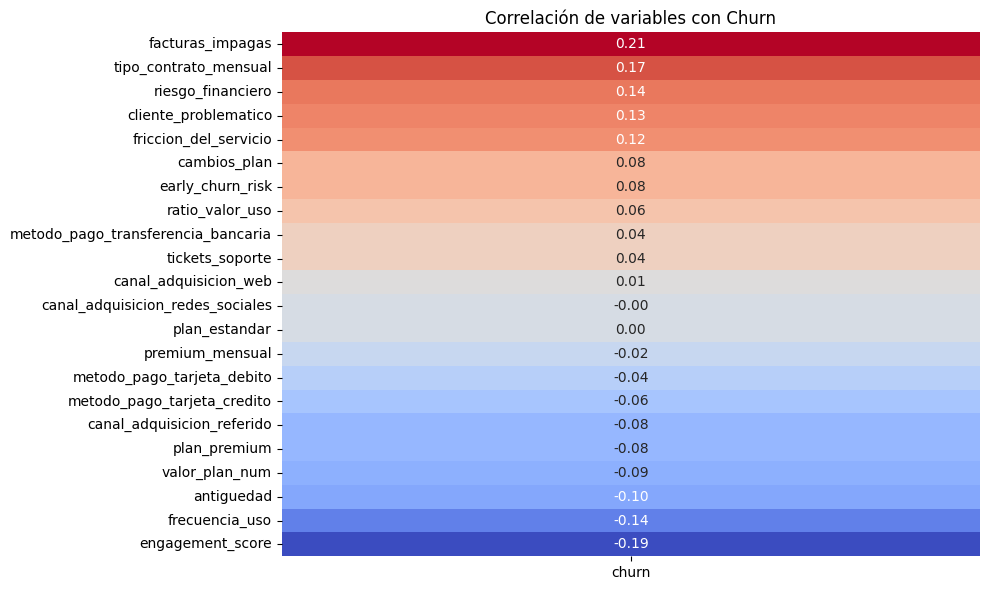

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr[["churn"]].sort_values(by="churn", ascending=False),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=False
)

plt.title("Correlación de variables con Churn")
plt.tight_layout()
plt.show()

## Analisis de correlacion


El análisis de correlación permite identificar qué variables presentan mayor asociación con el churn, entendiendo esta relación como no causal, sino indicativa de patrones de comportamiento.

Se observa que la variable ```facturas_impagas``` es la que presenta la mayor correlación positiva con el churn (r = 0.21, equivalente a un 21 %), lo que sugiere que los clientes con facturas impagas tienden a abandonar el servicio con mayor frecuencia. Aunque la correlación es moderada, resulta relevante considerando el carácter multifactorial del churn.

Por otro lado, ```engagement_score``` muestra la correlación negativa más alta (r = -0.19, aproximadamente -19 %), indicando que un mayor uso del servicio y mayor antigüedad se asocia con una menor probabilidad de abandono, lo que la posiciona como un posible factor de retención.

Asimismo, variables como ```plan_premium``` (r = -0.08, -8 %) y ```antiguedad``` (r = -0.10, -10 %) presentan correlaciones negativas débiles, lo que sugiere que los clientes con planes premium y mayor permanencia tienden ligeramente a mostrar menores tasas de churn, aunque su efecto individual es limitado.

En contraste, variables relacionadas con el método de pago y el canal de adquisición presentan correlaciones cercanas a cero (entre -1 % y 4 %), lo que indica que, de manera individual y lineal, no muestran una asociación significativa con el churn en este análisis.

---

Conclusión general:

El churn no depende de una única variable, sino de la combinación de múltiples factores. Sin embargo, ```facturas_impagas``` (21 %) y ```engagement_score``` (-19 %) emergen como las variables con mayor nivel de asociación, lo que justifica su priorización en análisis posteriores o en la construcción de un modelo predictivo.

# Analisis dirigido

se toma la siguiente regla para llevar a acabo este analisis:
#REGLA DE STURGES
k = 1 + (10/3) * np.log10(n)

In [ ]:
n = len(df)
k = int(1 + 3.322 * np.log10(n))
k

13

In [ ]:
df_codificado["frecuencia_uso_bin"] = pd.cut(
    df_codificado["frecuencia_uso"],
    bins=k
)

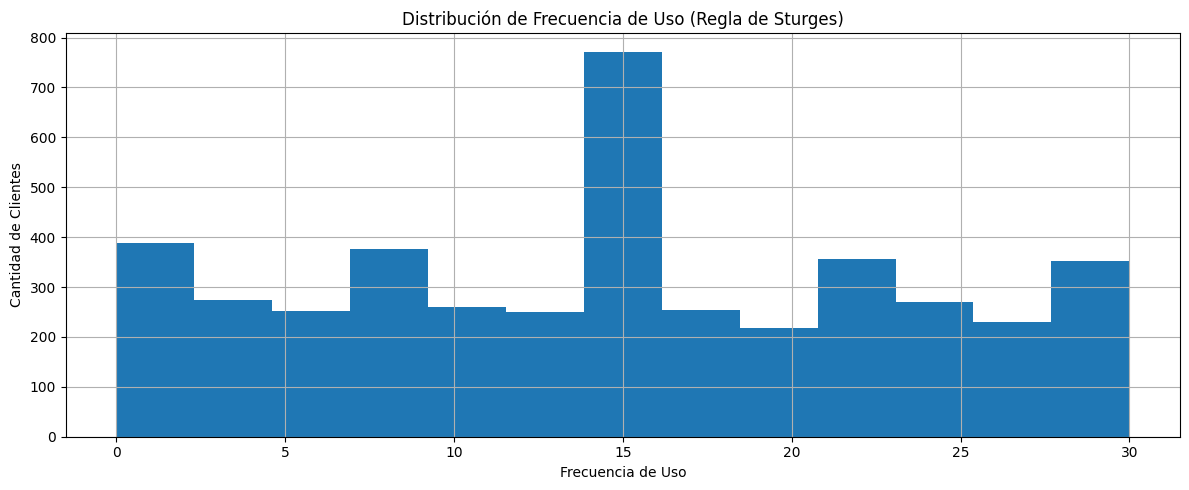

In [ ]:
plt.figure(figsize=(12, 5))

df["frecuencia_uso"].hist(bins=k)

plt.title("Distribución de Frecuencia de Uso (Regla de Sturges)")
plt.xlabel("Frecuencia de Uso")
plt.ylabel("Cantidad de Clientes")

plt.tight_layout()
plt.show()


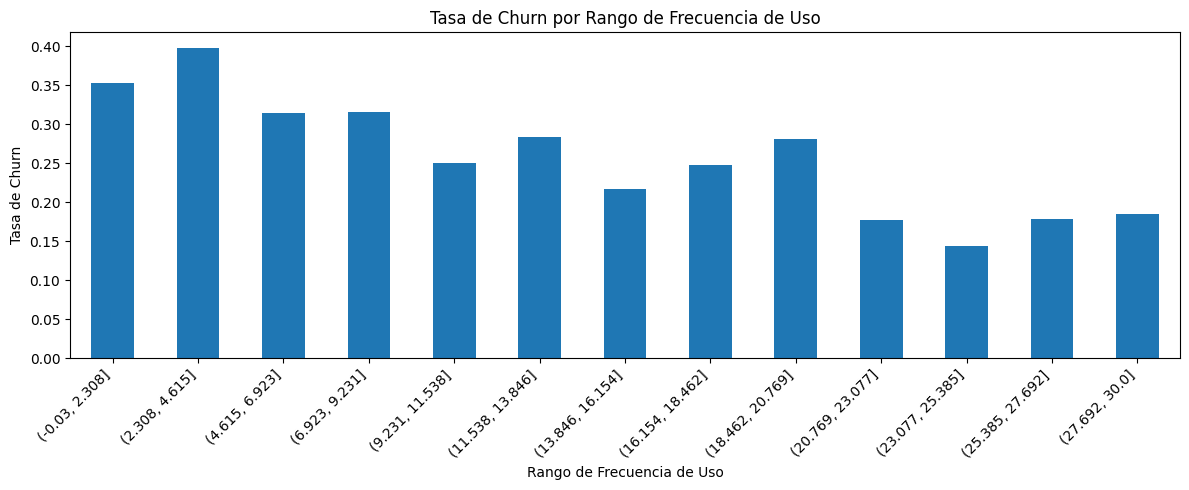

In [ ]:
churn_por_uso = (
    df
    .groupby("frecuencia_uso_bin")["churn"]
    .mean()
)

plt.figure(figsize=(12, 5))

churn_por_uso.plot(kind="bar")

plt.title("Tasa de Churn por Rango de Frecuencia de Uso")
plt.xlabel("Rango de Frecuencia de Uso")
plt.ylabel("Tasa de Churn")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


A partir de la segmentación de la variable Frecuencia de Uso mediante la regla de Sturges, se analizó la tasa promedio de churn en cada uno de los rangos definidos. Los resultados confirman una relación inversa entre la frecuencia de uso del servicio y la probabilidad de abandono.

Los rangos asociados a niveles bajos de uso presentan las tasas de churn más elevadas, con valores que alcanzan aproximadamente el 40 % en los primeros intervalos. A medida que la frecuencia de uso aumenta, se observa una tendencia general decreciente en la tasa de churn, la cual se reduce progresivamente hasta situarse alrededor del 10 % – 15 % en los rangos de mayor uso.

Este patrón refuerza la evidencia obtenida en el análisis de correlación, indicando que los clientes con mayor interacción con el servicio tienden a permanecer activos por más tiempo, mientras que aquellos con un bajo nivel de uso muestran una mayor propensión a cancelar el servicio. En consecuencia, la frecuencia de uso se consolida como una variable relevante para la retención de clientes y un criterio útil para la segmentación del riesgo de abandono en análisis posteriores o modelos predictivos.

## Distribución de clientes según tipo de plan

In [ ]:
ax = px.histogram(data_frame=df, x='plan', color='churn', barmode='group', title='Distribución de clientes según tipo de plan')
ax.show()

El gráfico muestra la distribución de clientes por tipo de plan, diferenciando entre aquellos que permanecen activos y los que presentan churn.
Se observa que el plan estándar concentra la mayor cantidad de clientes, tanto activos como con churn, lo que es consistente con su mayor nivel de adopción.

En términos relativos, el plan básico presenta una proporción de churn más elevada en comparación con el plan premium, el cual no solo tiene menos clientes totales, sino también una menor cantidad de cancelaciones. Esto sugiere que los clientes del plan premium tienden a ser más estables, mientras que el plan básico podría representar un segmento con mayor riesgo de abandono.

## Distribución de clientes según la forma de pago

In [ ]:
ax = px.histogram(data_frame=df, x='metodo_pago', color='churn', barmode='group', title='Distribución de clientes según la forma de pago')
ax.show()

El gráfico presenta la distribución de clientes según el método de pago, diferenciando entre clientes activos y aquellos que han cancelado el servicio (churn). Se observa que el método más utilizado es la tarjeta de débito, concentrando la mayor cantidad de clientes activos, aunque también presenta un volumen relevante de cancelaciones, en línea con su alta adopción.

Por otro lado, los clientes que pagan con tarjeta de crédito muestran una menor cantidad de casos de churn en comparación con otros métodos, lo que sugiere un mayor nivel de estabilidad. En contraste, los métodos de efectivo y transferencia bancaria presentan una proporción relativamente más alta de churn, lo que podría indicar una menor fidelización o un mayor riesgo de abandono en estos segmentos.

## Variabilidad en la antigüedad de los clientes

In [ ]:
ax = px.box(data_frame=df, x='antiguedad', color='churn', title='Variabilidad en la antigüedad de los clientes')
ax.show()

Este gráfico de cajas (box plot) compara la distribución de la antigüedad (en meses o años, según la unidad de medida) entre dos grupos de clientes: aquellos que permanecen en la empresa (*churn = 0*) y aquellos que han dejado el servicio (*churn = 1*).

---

Cada caja representa el rango intercuartílico (IQR), que abarca desde el percentil 25 (Q1) hasta el percentil 75 (Q3) de la antigüedad. La línea dentro de la caja indica la mediana (percentil 50). Los "bigotes" se extienden hasta los valores mínimo y máximo dentro de 1.5 veces el IQR, y los puntos fuera de ellos corresponden a valores atípicos (outliers).

---

Observaciones principales:

* Los clientes que se quedan (*churn = 0*) tienden a tener una antigüedad mayor, con una mediana más alta y una distribución general desplazada hacia valores superiores.

* Los clientes que abandonan (*churn = 1*) muestran una mediana menor y una dispersión más amplia en algunos casos, sugiriendo que la antigüedad baja puede estar asociada a una mayor probabilidad de abandono.

* La presencia de outliers en ambos grupos indica que existen casos de clientes con antigüedades excepcionalmente altas o bajas, lo cual podría merecer un análisis específico.

-----

La antigüedad del cliente parece ser un factor relevante en la retención. Estrategias enfocadas en clientes con menor antigüedad podrían ayudar a reducir el churn, por ejemplo, mediante programas de onboarding, incentivos de fidelización temprana o seguimiento cercano durante los primeros meses.

## Facturas impagas según antigüedad del cliente

In [ ]:
labels=['0-12', '13-24', '25-36', '37-48', '49-60', '60+']

df['antiguedad_bin'] = pd.cut(
    df['antiguedad'],
    bins=[0, 12, 24, 36, 48, 60, 120],
    labels=labels
)

ax = px.box(
    df,
    x='antiguedad_bin',
    y='facturas_impagas',
    color='churn',
    category_orders={'antiguedad_bin': labels},
    title='Facturas impagas según antigüedad del cliente'
)

ax.show()

Este gráfico de cajas múltiples analiza la distribución del número de facturas impagas en función de la antigüedad del cliente, segmentada en intervalos predefinidos y diferenciando entre clientes que permanecen (*churn = 0*, en azul) y los que abandonan (*churn = 1*, en rojo).

Los intervalos de antigüedad definidos son:

* 8-12, 13-24, 25-36, 37-48, 49-60, 60+ meses.

---

Ejes y lectura del gráfico:

* Eje Y: Intervalos de antigüedad (de menor a mayor antigüedad de abajo hacia arriba).

* Eje X: Número de facturas impagas (de 0 a aproximadamente 3).

* Color: Distingue entre clientes fieles (azul) y aquellos que han dado de baja el servicio (rojo).

---

Observaciones:

* Diferencias claras entre grupos de churn:
En todos los rangos de antigüedad, los clientes que abandonan (*churn = 1*) presentan una mediana de facturas impagas consistentemente más alta que los que se quedan (*churn = 0*). Esto sugiere que el impago es un predictor fuerte del abandono.

* Tendencia según antigüedad:
Para los clientes que se van (*churn = 1*), la cantidad de facturas impagas tiende a ser más alta en los segmentos de menor antigüedad (0-24 meses), lo que podría indicar que los clientes nuevos con problemas de pago tienen mayor probabilidad de abandonar tempranamente.

* Dispersión y valores atípicos:
En ambos grupos se observan outliers, especialmente en clientes con *churn = 1*, lo que indica que hay casos con un número excepcionalmente alto de facturas impagas, incluso en clientes con mayor antigüedad.

* Estabilidad en clientes leales:
Los clientes que permanecen (*churn = 0*) muestran una distribución muy concentrada cerca de cero facturas impagas en casi todos los intervalos, reforzando la relación entre puntualidad en pagos y fidelización.

---

Recomendaciones:

* Clientes nuevos (primeros 24 meses): Es crucial monitorear y gestionar proactivamente los impagos, ya que están más asociados al abandono.

* Acciones preventivas: Implementar recordatorios de pago, ofrecer facilidades de pago o contactar al cliente ante el primer impago puede reducir el churn.

* Segmentación de retención: Los clientes con dos o más facturas impagas, especialmente si son relativamente nuevos, podrían priorizarse en campañas de retención.

## Tickets abiertos a soporte según frecuencia de uso

In [ ]:
labels=['0-5', '5-10', '10-15', '15-20', '20-25', '25-30']

df['frecuencia_uso_bins'] = pd.cut(
    df['frecuencia_uso'],
    bins=[0, 5, 10, 15, 20, 25, 30],
    labels=labels
)

ax = px.box(
    df,
    x='frecuencia_uso_bins',
    y='tickets_soporte',
    color='churn',
    category_orders={'frecuencia_uso_bins': labels},
    title='Tickets abiertos a soporte según frecuencia de uso'
)

ax.show()

Este gráfico de cajas (box plot) explora la relación entre la frecuencia de uso del servicio (agrupada en intervalos) y el número de tickets abiertos a soporte, distinguiendo entre clientes que continúan en la empresa (*churn = 0*, en azul) y aquellos que la han abandonado (*churn = 1*, en rojo).

---

Los intervalos de frecuencia de uso considerados son:

* 0-5, 5-10, 10-15, 15-20, 20-25, 25-30 dias.

Estructura del gráfico:

* Eje X: Intervalos de frecuencia de uso, de menor a mayor uso.

* Eje Y: Número de tickets de soporte abiertos por el cliente.

* Color: Distingue el estado de churn (azul = se queda, rojo = se va).

---

* Relación entre uso y soporte:
Se observa una tendencia general: a mayor frecuencia de uso, mayor es el número mediano de tickets de soporte abiertos, en ambos grupos (*churn = 0 y 1*). Esto es esperable, ya que un uso más intensivo del servicio puede generar más consultas, incidencias o necesidades de asistencia.

* Diferencias marcadas por churn:
En casi todos los intervalos de uso, los clientes que abandonan (*churn = 1*) presentan una mediana de tickets de soporte significativamente mayor que los clientes que permanecen (*churn = 0*). Esto sugiere que una elevada interacción con soporte puede estar asociada a una experiencia insatisfactoria o a problemas recurrentes no resueltos, lo que incrementa la probabilidad de abandono.

* Dispersión y valores atípicos (outliers):
Ambos grupos muestran outliers, especialmente en el grupo de *churn = 1*, donde hay clientes con un número excepcionalmente alto de tickets incluso en rangos de uso moderado. Esto podría indicar que, para algunos clientes, la acumulación de problemas y la necesidad recurrente de soporte son factores críticos en la decisión de irse.

* Clientes con bajo uso pero alto soporte:
En el rango de menor frecuencia de uso (0-5), ya se observa una diferencia notable entre grupos, lo que indica que incluso los usuarios ocasionales que requieren mucho soporte tienen mayor riesgo de churn.

---

Recomendaciones:

* Soporte proactivo: Los clientes con frecuencia de uso media-alta y un número creciente de tickets deben ser monitoreados de cerca, ya que podrían estar experimentando fricciones repetidas.

* Calidad de la atención: Mejorar la resolución en primer contacto y reducir la necesidad de reapertura de tickets podría disminuir el churn entre usuarios activos.

* Segmentación para retención: Los clientes que abren más de 2-3 tickets, independientemente de su frecuencia de uso, podrían ser candidatos a intervenciones de retención o encuestas de satisfacción.

## Relación entre cambios de plan y churn

In [ ]:
ax = px.histogram(data_frame=df, x='cambios_plan', color='churn', barmode='group', title='Relación entre cambios de plan y churn')
ax.show()

Este gráfico de histogramas agrupados analiza la distribución de clientes según el número de cambios de plan que han realizado, diferenciando entre aquellos que permanecen en la empresa (*churn = 0*) y los que han abandonado el servicio (*churn = 1*).

---

Observaciones:

* Distribución dominante en 0 cambios de plan:
La gran mayoría de los clientes, tanto los que se quedan como los que abandonan, no han realizado cambios de plan. Esto sugiere que la inercia o la satisfacción con el plan inicial son comunes en la base de clientes.

* Relación entre cambios de plan y churn:
A medida que aumenta el número de cambios de plan, la proporción de clientes que abandonan (*churn = 1*) tiende a crecer en relación con los que se quedan. Esto indica que los clientes que realizan múltiples cambios podrían estar experimentando insatisfacción, inestabilidad en sus necesidades, o buscando alternativas antes de abandonar definitivamente.

* Clientes con 1 cambio de plan:
En este grupo, ya se observa una proporción notablemente mayor de *churn = 1* en comparación con los que no han realizado cambios. Un cambio de plan puede ser un indicador temprano de insatisfacción o de reevaluación del servicio.

* Cambios múltiples (2 o más):
Aunque el volumen de clientes es menor, la proporción de abandonos es significativamente más alta. Esto refuerza la hipótesis de que la inestabilidad en la elección del plan está asociada a una mayor probabilidad de abandono.

---

Recomendaciones:

* Monitoreo proactivo: Los clientes que realizan su primer cambio de plan deberían ser considerados para seguimiento o encuestas de satisfacción, ya que podrían estar en riesgo.

* Flexibilidad vs. estabilidad: Ofrecer flexibilidad en los planes es valioso, pero múltiples cambios pueden señalar problemas subyacentes (ej.: planes poco claros, expectativas no alineadas).

* Retención personalizada: Clientes con 2 o más cambios podrían beneficiarse de ofertas personalizadas, asesoría en la elección del plan, o programas de fidelización diseñados para reducir la rotación.